# 5장 실습 — 잔차로 메우기

4장에서 시스템 식별이 어디까지 가는지 봤다. 전용 실험을 설계하면 물리 파라미터는 정확히 되찾힌다. 그런데 마지막에 남은 것이 있었다 — **모델에 아예 없는 항**은 파라미터를 아무리 정밀하게 다듬어도 되찾을 수 없다.

이 노트북은 그 남은 것을 다룬다. 모델을 고치는 대신 **모델과 실기의 차이만 따로 배운다.** 잔차 모델이라고 부르고, 액추에이터에 쓰면 델타 액션 모델, 전신 제어에 쓰면 ASAP 같은 이름이 붙는다. 원리는 하나다.

이번 실기에는 시뮬 모델이 표현할 수 없는 항을 심어 둔다. **데드존**이다. 명령이 작으면 구동기가 아예 안 움직인다. 실제 모터의 정지 마찰과 드라이버 임계에서 늘 생기는 현상인데, 마찰계수나 게인을 어떻게 바꿔도 이것을 흉내 낼 수 없다.

실행 시간은 CPU에서 3분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import unicodedata
import numpy as np
import mujoco
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    # 화면에서 차지하는 칸 수. 한글은 한 글자가 두 칸이다
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    # f"{s:<12}" 는 글자 수로 세어 한글 표를 어긋나게 한다
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
print("mujoco", mujoco.__version__)

mujoco 3.13.0


## 실기에 모델 밖의 항을 심는다

물리 모델은 4장과 같다. 달라지는 것은 명령이 구동기에 닿기 **전에** 거치는 변환이다.

> 명령의 크기가 δ 보다 작으면 0, 그보다 크면 δ 만큼 깎인 뒤 s 배로 스케일된다

데드존 폭 δ 안에서는 명령이 사라지고, 그 밖에서는 크기가 δ만큼 깎인 뒤 s배로 스케일된다. 시뮬 쪽 모델에는 이 변환이 없다. **마찰도 게인도 지연도 이것을 흉내 낼 수 없다.**

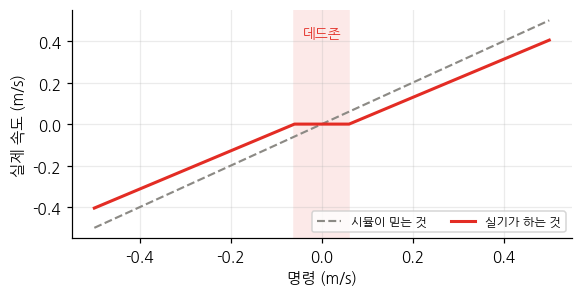

In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction="{mu} .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom name="block" type="cylinder" size=".03 .03" mass=".25"
            friction="{mu} .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom name="pusher" type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="{kv}"/>
    <velocity joint="py" kv="{kv}"/>
  </actuator>
</mujoco>
'''

CTRL_HZ, EP_STEPS = 20, 140
GOAL_R, STANDOFF, STOP = .04, .045, .015
MU, KV, LAT, NOISE = .60, 120., 2, .004
DEAD, SCALE = .06, .92          # 실기에만 있는 데드존과 스케일


def make(mu=MU, kv=KV):
    m = mujoco.MjModel.from_xml_string(XML.format(mu=mu, kv=kv))
    return m, mujoco.MjData(m)


def unit(v):
    n = np.linalg.norm(v)
    return v / n if n > 1e-9 else np.zeros_like(v)


def deadzone(u):
    # 실기 구동기가 명령에 실제로 하는 일
    a = np.abs(u)
    out = np.where(a < DEAD, 0., SCALE * (a - DEAD) * np.sign(u))
    return out


def reset(m, d, rng):
    mujoco.mj_resetData(m, d)
    bx, by = rng.uniform(-.03, .03, 2)
    d.qpos[0:2] = [bx, by]
    d.qpos[2] = .031
    d.qpos[7:9] = [bx - .09, by]
    mujoco.mj_forward(m, d)
    return np.array([.28, 0.]) + rng.uniform(-.04, .04, 2)


us = np.linspace(-.5, .5, 201)
fig, ax = plt.subplots(figsize=(5.4, 2.8))
ax.plot(us, us, "--", color=GREY, lw=1.4, label="시뮬이 믿는 것")
ax.plot(us, deadzone(us), "-", color=RED, lw=2.0,
        label="실기가 하는 것")
ax.axvspan(-DEAD, DEAD, color="#FCE9E8", zorder=0)
ax.text(0, .42, "데드존", ha="center", fontsize=9, color=RED)
ax.set_xlabel("명령 (m/s)")
ax.set_ylabel("실제 속도 (m/s)")
ax.legend(fontsize=8, ncol=2, loc="lower right")
plt.tight_layout()
plt.show()

## 실기와 시뮬을 세운다

같은 함수에 `real=True` 를 주면 데드존을 거치고, 아니면 명령이 그대로 간다. 이 스위치 하나가 이 노트북의 전부다.

In [4]:
def rollout(m, d, rng, pol, real=False, noise=0., lat=LAT,
            corr=None, keep=False):
    # real 이면 명령이 데드존을 거친다. corr 은 잔차 보정 함수다
    goal = reset(m, d, rng)
    sub = int(round(1 / CTRL_HZ / m.opt.timestep))
    buf = [np.zeros(2)] * (lat + 1)
    log = []
    for t in range(EP_STEPS):
        b = d.qpos[0:2]
        if noise:
            b = b + rng.normal(0, noise, 2)
        u = pol(np.asarray(b), np.asarray(d.qpos[7:9]), goal, t)
        if corr is not None:
            u = corr(u)
        buf.append(u)
        cmd = buf[-1 - lat]
        d.ctrl[:] = deadzone(cmd) if real else cmd
        for _ in range(sub):
            mujoco.mj_step(m, d)
        if keep:
            log.append((cmd.copy(), d.qvel[6:8].copy()))
    ok = np.linalg.norm(d.qpos[0:2] - goal) < GOAL_R
    return (ok, log) if keep else ok

## 먼저 시스템 식별을 다시 돌려 본다

잔차로 넘어가기 전에, 4장의 방법으로는 정말 못 메우는지 확인한다. 접촉 없는 추종 실험으로 게인과 지연을 다시 추정해 본다. 실기에는 데드존이 있으니, 추정기는 그것을 게인이 낮은 것으로 착각할 것이다.

In [5]:
def track(kv, lat, real=False, noise=0., rng=None, amp=.30):
    # 접촉 없이 밀대만 명령을 따라간다
    m, d = make(kv=kv)
    mujoco.mj_resetData(m, d)
    d.qpos[0:2] = [2., 2.]
    d.qpos[2] = .031
    mujoco.mj_forward(m, d)
    sub = int(round(1 / CTRL_HZ / m.opt.timestep))
    t = np.arange(80)
    cmd = np.stack([amp * np.sin(2 * np.pi * t / 14),
                    amp * np.cos(2 * np.pi * t / 9)], 1)
    buf = [np.zeros(2)] * (lat + 1)
    path = []
    for k in range(80):
        buf.append(cmd[k])
        c = buf[-1 - lat]
        d.ctrl[:] = deadzone(c) if real else c
        for _ in range(sub):
            mujoco.mj_step(m, d)
        p = d.qpos[7:9].copy()
        if noise:
            p = p + rng.normal(0, noise, 2)
        path.append(p)
    return np.array(path)


rng = np.random.default_rng(1)
obs = track(KV, LAT, real=True, noise=NOISE, rng=rng)
rows = []
for kv in (40., 60., 90., 120., 160., 220., 300.):
    for lat in range(0, 5):
        dif = track(kv, lat) - obs
        e = float(np.linalg.norm(dif, axis=1).mean())
        rows.append((e, kv, lat))
rows.sort()
KV_HAT, LAT_HAT = rows[0][1], int(rows[0][2])

print(pad("순위", 6) + pad("게인", 9, True) + pad("지연", 8, True)
      + pad("추종 오차", 13, True))
for r, (e, kv, lat) in enumerate(rows[:4], 1):
    print(pad(r, 6) + pad(f"{kv:g}", 9, True) + pad(lat, 8, True)
          + pad(f"{e*1000:.2f} mm", 13, True))
print()
print(f"추정 게인 {KV_HAT:g} (참값 {KV:g}),"
      f" 지연 {LAT_HAT} (참값 {LAT})")
print(f"가장 잘 맞춘 모델의 남은 오차 {rows[0][0]*1000:.2f} mm")

순위       게인    지연    추종 오차
1            40       1     15.75 mm
2            60       2     16.13 mm
3            40       2     16.15 mm
4            90       2     16.47 mm

추정 게인 40 (참값 120), 지연 1 (참값 2)
가장 잘 맞춘 모델의 남은 오차 15.75 mm


## 잔차를 배운다

이제 다른 길로 간다. 모델을 고치려 하지 않고, 명령과 실제 속도 사이의 관계를 **데이터에서 직접** 배운다.

관측할 수 있는 것은 명령과 밀대의 실제 속도다. 둘을 짝지어 모으면 그 사이의 사상을 그릴 수 있다. 여기서는 구간별 평균으로 배운다 — 명령을 스물한 개 구간으로 나누고 구간마다 실제 속도의 평균을 기억한다. 신경망을 쓸 수도 있지만, 배울 것이 일차원 사상 하나라면 이쪽이 더 정직하고 빠르다.

In [6]:
def collect(n=40, amp_lo=.08, amp_hi=.45, seed=0):
    # 여러 진폭의 명령을 실기에 넣고 (명령, 실제 속도) 를 모은다
    rng = np.random.default_rng(seed)
    m, d = make()
    sub = int(round(1 / CTRL_HZ / m.opt.timestep))
    U, V = [], []
    for e in range(n):
        mujoco.mj_resetData(m, d)
        d.qpos[0:2] = [2., 2.]
        d.qpos[2] = .031
        mujoco.mj_forward(m, d)
        amp = rng.uniform(amp_lo, amp_hi)
        per = rng.uniform(8, 26)
        ph = rng.uniform(0, 2 * np.pi)
        for k in range(60):
            u = np.array([amp * np.sin(2 * np.pi * k / per + ph),
                          amp * np.cos(2 * np.pi * k / per)])
            d.ctrl[:] = deadzone(u)
            for _ in range(sub):
                mujoco.mj_step(m, d)
            U.append(u.copy())
            V.append(d.qvel[6:8].copy())
    return np.concatenate(U), np.concatenate(V)


EDGES = np.linspace(-.5, .5, 22)
CENT = (EDGES[:-1] + EDGES[1:]) / 2


def fit_residual(U, V):
    # 명령 구간마다 실제 속도의 평균을 기억한다
    idx = np.clip(np.digitize(U, EDGES) - 1, 0, len(CENT) - 1)
    tab = np.array([V[idx == b].mean() if (idx == b).sum() > 8
                    else np.nan for b in range(len(CENT))])
    good = ~np.isnan(tab)
    return np.interp(CENT, CENT[good], tab[good])


U, V = collect()
TAB = fit_residual(U, V)
print(f"표본 {len(U):,}개로 구간 {len(CENT)}개를 채웠다")

표본 4,800개로 구간 21개를 채웠다


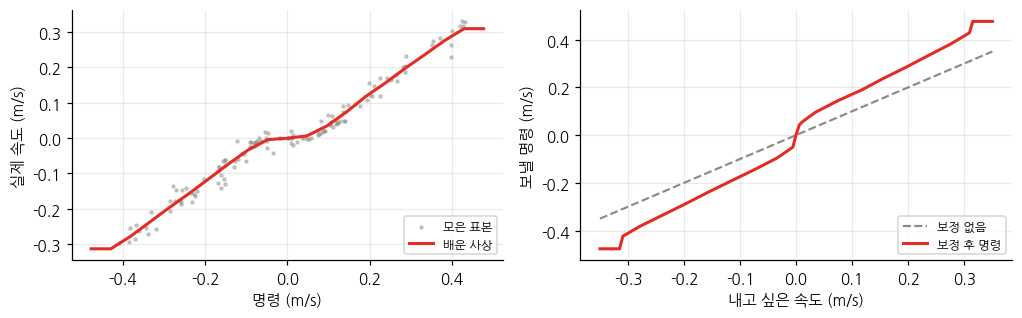

In [7]:
def invert(target):
    # 원하는 속도를 내려면 명령을 얼마나 줘야 하는가
    order = np.argsort(TAB)
    return np.interp(target, TAB[order], CENT[order])


def correct(u):
    # 정책이 낸 명령을 실기 구동기에 맞게 미리 부풀린다
    return np.array([invert(u[0]), invert(u[1])])


fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.4, 3.0))
a1.scatter(U[::37], V[::37], s=4, color=GREY, alpha=.4,
           label="모은 표본")
a1.plot(CENT, TAB, "-", color=RED, lw=2.0, label="배운 사상")
a1.set_xlabel("명령 (m/s)")
a1.set_ylabel("실제 속도 (m/s)")
a1.legend(fontsize=8, loc="lower right")

tgt = np.linspace(-.35, .35, 121)
a2.plot(tgt, tgt, "--", color=GREY, lw=1.4, label="보정 없음")
a2.plot(tgt, invert(tgt), "-", color=RED, lw=2.0,
        label="보정 후 명령")
a2.set_xlabel("내고 싶은 속도 (m/s)")
a2.set_ylabel("보낼 명령 (m/s)")
a2.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

## 3장의 자로 채점한다

네 가지를 견준다. 아무것도 안 한 시뮬, 4장 방식으로 게인만 다시 맞춘 시뮬, 잔차 보정을 정책에 붙인 것, 그리고 잔차 보정 없이 잔차를 **시뮬 쪽에** 넣어 실기를 흉내 낸 것이다.

마지막이 중요하다. 잔차 모델은 두 가지로 쓸 수 있다. 정책이 내는 명령을 실기에 맞게 **미리 보정**하거나, 시뮬이 실기처럼 굴게 **시뮬을 고치는** 것이다. 앞쪽은 실기 성능을 올리고 뒤쪽은 시뮬의 예측력을 올린다. 목적이 다르다.

In [8]:
def _behind(b, g):
    return b - unit(g - b) * STANDOFF


def mk_push(speed, release=0., period=0):
    def pol(b, p, g, t):
        rem = np.linalg.norm(g - b)
        if rem < max(release, STOP):
            return np.zeros(2)
        if period and t % period >= period - 6:
            return -unit(g - b) * speed * .5
        c = _behind(b, g)
        if np.linalg.norm(p - c) > .012:
            return unit(c - p) * max(speed, .3)
        return unit(g - b) * speed
    return pol


def mk_servo(K, speed):
    def pol(b, p, g, t):
        if np.linalg.norm(g - b) < STOP:
            return np.zeros(2)
        e = _behind(b, g) - p
        near = np.linalg.norm(e) < .015
        v = K * e + unit(g - b) * speed * near
        return np.clip(v, -1.2, 1.2)
    return pol


def mk_fine(speed, tol):
    def pol(b, p, g, t):
        rem = np.linalg.norm(g - b)
        if rem < tol:
            return np.zeros(2)
        c = _behind(b, g)
        if np.linalg.norm(p - c) > .010:
            return unit(c - p) * .30
        return unit(g - b) * (speed if rem > .06 else speed * .35)
    return pol


POLICIES = {
    "직진":         mk_push(.25),
    "살살":         mk_push(.12),
    "밀고 물러나기": mk_push(.30, period=22),
    "돌진-코스트":   mk_push(.60, release=.11),
    "빠른 서보":     mk_servo(14., .25),
    "정밀 정렬":     mk_fine(.25, .006),
}
NAMES = list(POLICIES)


def rates(kv=KV, real=False, noise=0., lat=LAT, sim_dead=False,
          n=100):
    m, d = make(kv=kv)
    out = []
    for p in POLICIES.values():
        s = 0
        for i in range(n):
            s += rollout(m, d, np.random.default_rng(i), p,
                         real=(real or sim_dead), noise=noise,
                         lat=lat)
        out.append(s / n)
    return np.array(out)


def pearson(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    x, y = x - x.mean(), y - y.mean()
    den = np.sqrt((x * x).sum() * (y * y).sum())
    return float((x * y).sum() / den) if den > 1e-12 else np.nan


def mmrv(realr, simr):
    r, s = np.asarray(realr, float), np.asarray(simr, float)
    worst = np.zeros(len(r))
    for i in range(len(r)):
        v = 0.
        for j in range(len(r)):
            if i == j:
                continue
            if np.sign(r[i] - r[j]) != np.sign(s[i] - s[j]):
                v = max(v, abs(r[i] - r[j]))
        worst[i] = v
    return float(worst.mean())

In [9]:
rv = rates(real=True, noise=NOISE)          # 실기
CAND = {
    "그대로":        dict(kv=KV),
    "게인만 다시":   dict(kv=KV_HAT, lat=LAT_HAT),
    "잔차를 시뮬에": dict(kv=KV, sim_dead=True),
    "잔차 + 잡음":   dict(kv=KV, sim_dead=True, noise=NOISE),
}
sims, score = {}, {}
for name, kw in CAND.items():
    sims[name] = rates(**kw)
    score[name] = (mmrv(rv, sims[name]), pearson(rv, sims[name]))

labels = list(CAND)
print(pad("정책", 16) + pad("실기", 9, True)
      + "".join(pad(s, 15, True) for s in labels))
for i, k in enumerate(NAMES):
    row = "".join(pad(f"{sims[s][i]:.2f}", 15, True)
                  for s in labels)
    print(pad(k, 16) + pad(f"{rv[i]:.2f}", 9, True) + row)
print()
print(pad("시뮬", 16) + pad("MMRV ↓", 12, True)
      + pad("Pearson r ↑", 16, True))
for s in labels:
    print(pad(s, 16) + pad(f"{score[s][0]:.3f}", 12, True)
          + pad(f"{score[s][1]:.3f}", 16, True))

정책                 실기         그대로    게인만 다시  잔차를 시뮬에    잔차 + 잡음
직진                 0.88           0.97           0.09           0.86           0.88
살살                 0.00           0.03           0.00           0.00           0.00
밀고 물러나기        0.71           0.76           0.63           0.85           0.71
돌진-코스트          0.08           0.12           0.09           0.34           0.08
빠른 서보            0.58           0.08           0.62           0.69           0.58
정밀 정렬            0.41           0.84           0.00           0.03           0.41

시뮬                  MMRV ↓     Pearson r ↑
그대로                 0.267           0.730
게인만 다시            0.482           0.491
잔차를 시뮬에          0.110           0.831
잔차 + 잡음            0.000           1.000


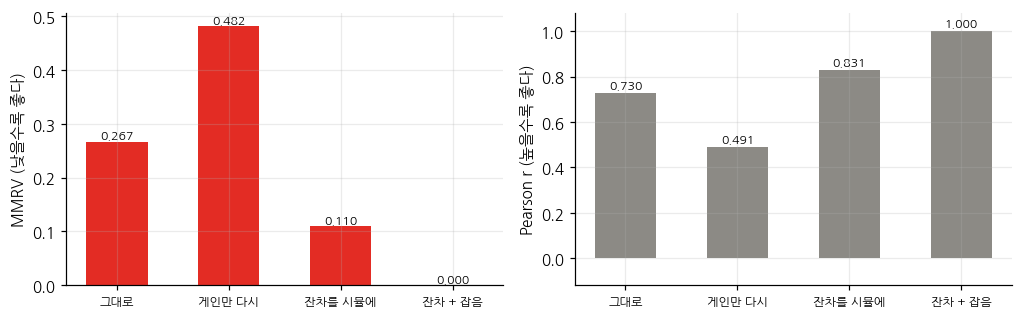

In [10]:
mm = [score[s][0] for s in labels]
pr = [score[s][1] for s in labels]
x = np.arange(len(labels))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.4, 3.0))
a1.bar(x, mm, color=RED, width=.55)
a1.set_ylabel("MMRV (낮을수록 좋다)")
for i, v in enumerate(mm):
    a1.text(i, v + .006, f"{v:.3f}", ha="center", fontsize=8)
a2.bar(x, pr, color=GREY, width=.55)
a2.set_ylabel("Pearson r (높을수록 좋다)")
a2.set_ylim(min(0, min(pr)) - .12, 1.08)
for i, v in enumerate(pr):
    a2.text(i, v + .02, f"{v:.3f}", ha="center", fontsize=8)
for a in (a1, a2):
    a.set_xticks(x)
    a.set_xticklabels(labels, fontsize=8)
plt.tight_layout()
plt.show()

## 보정을 정책에 붙이면 실기가 좋아지는가

앞 절은 시뮬의 예측력을 봤다. 이번에는 반대쪽이다. 잔차 보정을 정책이 내는 명령에 붙여 **실기 성능**을 재 본다.

In [11]:
def real_rates(corr=None, n=100):
    m, d = make()
    out = []
    for p in POLICIES.values():
        s = 0
        for i in range(n):
            s += rollout(m, d, np.random.default_rng(i), p,
                         real=True, noise=NOISE, corr=corr)
        out.append(s / n)
    return np.array(out)


base = real_rates()
fixed = real_rates(correct)

print(pad("정책", 16) + pad("보정 없음", 12, True)
      + pad("잔차 보정", 12, True) + pad("차이", 10, True))
for i, k in enumerate(NAMES):
    print(pad(k, 16) + pad(f"{base[i]:.2f}", 12, True)
          + pad(f"{fixed[i]:.2f}", 12, True)
          + pad(f"{fixed[i]-base[i]:+.2f}", 10, True))
print()
print(f"평균  {base.mean():.3f} → {fixed.mean():.3f}"
      f"  ({fixed.mean()-base.mean():+.3f})")

정책               보정 없음   잔차 보정      차이
직진                    0.88        0.70     -0.18
살살                    0.00        0.29     +0.29
밀고 물러나기           0.71        0.49     -0.22
돌진-코스트             0.08        0.00     -0.08
빠른 서보               0.58        0.49     -0.09
정밀 정렬               0.41        0.72     +0.31

평균  0.443 → 0.448  (+0.005)


## 잔차 모델 자체는 얼마나 정확한가

과제 성공률로는 모델의 품질과 정책의 튜닝이 뒤섞인다. 둘을 떼어 놓고 **모델만** 재 본다. 내고 싶은 속도를 정하고, 보정을 거친 명령을 실기에 넣어 실제로 얼마가 나오는지 본다.

같은 방법으로 잔차를 세 번 배운다. 전 구간에서 배운 것, 빠른 명령만 보고 배운 것, 느린 명령만 보고 배운 것이다. 데이터를 모은 범위가 결과를 어떻게 가르는지 보기 위해서다.

In [12]:
def achieve(target, corr=None):
    # 이 속도를 내고 싶다. 실제로 얼마가 나오는가
    m, d = make()
    mujoco.mj_resetData(m, d)
    d.qpos[0:2] = [2., 2.]
    d.qpos[2] = .031
    mujoco.mj_forward(m, d)
    u = np.array([target, 0.])
    if corr is not None:
        u = corr(u)
    for _ in range(60):
        d.ctrl[:] = deadzone(u)
        mujoco.mj_step(m, d)
    return float(d.qvel[6])


TAB_FULL = TAB.copy()
TAB_HIGH = fit_residual(
    *collect(n=40, amp_lo=.25, amp_hi=.45, seed=7))
TAB_LOW = fit_residual(
    *collect(n=40, amp_lo=.03, amp_hi=.12, seed=8))

tg = np.linspace(.01, .40, 40)
curves = {}
for name, tab in (("보정 없음", None), ("전 구간", TAB_FULL),
                  ("고속만", TAB_HIGH), ("저속만", TAB_LOW)):
    if tab is None:
        curves[name] = [achieve(v) for v in tg]
        continue
    TAB = tab
    curves[name] = [achieve(v, correct) for v in tg]
TAB = TAB_FULL

lo, hi = tg < .12, tg > .25     # 각 잔차가 본 곳과 못 본 곳
print(pad("잔차 모델", 12) + pad("전체", 12, True)
      + pad("저속 구간", 12, True) + pad("고속 구간", 12, True))
for k, v in curves.items():
    e = np.abs(np.array(v) - tg) * 1000
    print(pad(k, 12) + pad(f"{e.mean():.1f}", 12, True)
          + pad(f"{e[lo].mean():.1f}", 12, True)
          + pad(f"{e[hi].mean():.1f}", 12, True))
print("\n단위는 mm/s. 낮을수록 명령대로 나온다.")

잔차 모델           전체   저속 구간   고속 구간
보정 없음           68.3        47.5        81.9
전 구간             15.1         3.4        28.9
고속만              15.8         6.4        27.3
저속만             160.6       256.5        55.8

단위는 mm/s. 낮을수록 명령대로 나온다.


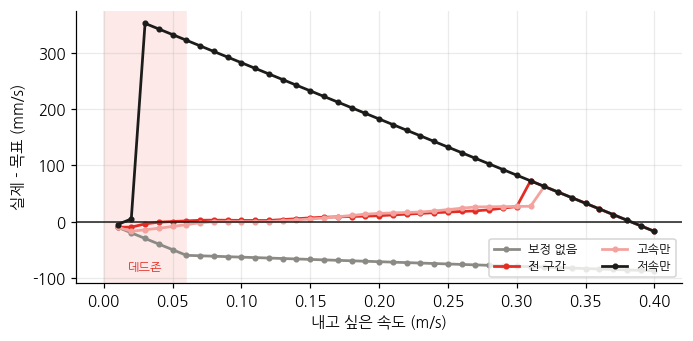

In [13]:
fig, ax = plt.subplots(figsize=(6.4, 3.2))
cols = (GREY, RED, "#F3A29D", INK)
for k, col in zip(curves, cols):
    ax.plot(tg, (np.array(curves[k]) - tg) * 1000, "o-", color=col,
            lw=1.8, ms=3, label=k)
ax.axhline(0, color=INK, lw=1)
ax.axvspan(0, DEAD, color="#FCE9E8", zorder=0)
ax.text(DEAD / 2, ax.get_ylim()[0] * .8, "데드존", ha="center",
        fontsize=8, color=RED)
ax.set_xlabel("내고 싶은 속도 (m/s)")
ax.set_ylabel("실제 - 목표 (mm/s)")
ax.legend(fontsize=8, ncol=2, loc="lower right")
plt.tight_layout()
plt.show()

## 정리

**모델에 없는 항은 파라미터로 못 메운다.** 데드존이 있는 실기를 데드존 없는 모델로 맞추면 추정기가 게인을 엉뚱한 값으로 끌고 가고, 그래도 오차가 남는다. 4장에서 「시스템 식별은 값이 아니라 구조를 맞추는 일」이라고 한 것이 이 자리다.

**잔차 모델은 구조를 고치는 대신 차이를 외운다.** 명령과 실제 속도를 짝지어 모으면 사상 하나가 나오고, 그것을 뒤집으면 보정 함수가 된다. 신경망도 미분가능 시뮬레이터도 필요 없었다.

**쓰는 방향이 둘이고 채점하는 자도 둘이다.** 잔차를 시뮬 쪽에 넣으면 시뮬의 예측력이 올라간다 — 3장의 자로 채점된다. 정책의 명령에 붙이면 실기 플랜트를 바꾼다 — 이쪽은 실기 성공률로 채점된다.

**그런데 보정을 붙이면 정책을 다시 맞춰야 한다.** 보정 없이 손으로 맞춘 정책 여섯에 보정만 얹었더니 느린 정책은 크게 좋아지고 빠른 정책은 나빠져서 평균이 제자리였다. 보정은 플랜트의 실효 이득을 바꾸는 일이고, 플랜트가 바뀌면 그 위에 얹힌 튜닝도 다시 해야 한다. 실무에서 자주 놓치는 순서다.

**잔차 모델의 신뢰 범위는 폭이 아니라 단조성이 정한다.** 모델 자체의 정확도를 따로 재 보니, 빠른 명령만 보고 배운 잔차는 보지 않은 구간까지 잘 맞았고 느린 명령만 보고 배운 잔차는 보정을 안 한 것보다 나빴다. 앞쪽은 사상이 직선이라 외삽이 통했고, 뒤쪽은 데드존 안에서 입력이 출력과 일대일로 대응하지 않아 역함수 자체가 성립하지 않았다. 자극을 설계할 때 볼 것은 진폭의 폭이 아니라 그 구간에서 사상을 뒤집을 수 있는가이다.

다음 두 장은 반대 방향이다. 시뮬을 실기에 맞추는 대신, **시뮬이 틀려 있다는 것을 전제하고** 그래도 통하는 정책을 만드는 길을 간다.